# Exercício 2 — Ordenações quadráticas com instrumentação e diagnóstico

**Henrique Goldstein Maluhy Mendes Amaral** · DR1_AT — Algoritmos e Estruturas de Dados · Infnet

Para rodar: **Ambiente de execução → Executar tudo**. O notebook é independente, não precisa de nenhum arquivo externo.

**Roteiro:** (1) bubble, selection e insertion contando comparações e cópias · (2) experimento com 4 padrões × 4 tamanhos · (3) quem ganha no "quase ordenado" e por quê · (4) BST para validar a ordenação e comparação de custo com o insertion · (5) remoção na BST · (6) casos de borda

In [1]:
import random

import matplotlib.pyplot as plt
import pandas as pd

random.seed(42)

## 1. Os três algoritmos

Os três trabalham numa **cópia** da lista (a entrada não é alterada) e devolvem `(lista_ordenada, comparacoes, copias)`.

Regras de contagem, iguais para os três:
- **comparação** = cada vez que comparo duas chaves da lista;
- **cópia** = cada vez que um valor é escrito numa posição. Uma **troca vale 3 cópias** (`tmp = a; a = b; b = tmp`), como pede o enunciado.

In [2]:
def bubble_sort(lista):
    lista = lista.copy()
    n = len(lista)
    comparacoes = copias = 0
    for i in range(n):
        trocou = False
        # a cada passada o maior elemento que sobrou "borbulha" para o fim
        for j in range(0, n - i - 1):
            comparacoes += 1
            if lista[j] > lista[j + 1]:
                lista[j], lista[j + 1] = lista[j + 1], lista[j]
                copias += 3
                trocou = True
        # se uma passada inteira não trocou nada, a lista já está ordenada
        if not trocou:
            break
    return lista, comparacoes, copias


def selection_sort(lista):
    lista = lista.copy()
    n = len(lista)
    comparacoes = copias = 0
    for i in range(n):
        # procuro o menor elemento na parte que ainda não foi ordenada
        min_index = i
        for j in range(i + 1, n):
            comparacoes += 1
            if lista[j] < lista[min_index]:
                min_index = j
        # só troco se o menor não já estiver no lugar
        if min_index != i:
            lista[i], lista[min_index] = lista[min_index], lista[i]
            copias += 3
    return lista, comparacoes, copias


def insertion_sort(lista):
    lista = lista.copy()
    comparacoes = copias = 0
    for i in range(1, len(lista)):
        chave = lista[i]
        copias += 1
        j = i - 1
        # empurro para a direita os elementos maiores que a chave
        while j >= 0:
            comparacoes += 1
            if lista[j] <= chave:
                break
            lista[j + 1] = lista[j]   # desloca: 1 cópia, não uma troca
            copias += 1
            j -= 1
        lista[j + 1] = chave
        copias += 1
    return lista, comparacoes, copias


ALGORITMOS = {"bubble": bubble_sort, "selection": selection_sort, "insertion": insertion_sort}

# conferindo antes de medir
exemplo = [64, 34, 25, 12, 22, 11, 90, 18, 8, 9]
for nome, ordenar in ALGORITMOS.items():
    saida, _, _ = ordenar(exemplo)
    assert saida == sorted(exemplo), nome
assert exemplo == [64, 34, 25, 12, 22, 11, 90, 18, 8, 9]   # a entrada não foi mexida
print("os três ordenam corretamente e não alteram a entrada")

os três ordenam corretamente e não alteram a entrada


## 2. Os quatro padrões de entrada

- **ordenado** e **reverso**: os extremos;
- **aleatório**: embaralhado com semente fixa, para o experimento ser reproduzível;
- **quase ordenado**: começa ordenado e 5% das posições trocam com um vizinho até 10 casas de distância.

In [3]:
def gerar_padrao(n, padrao):
    if padrao == "ordenado":
        return list(range(n))
    if padrao == "reverso":
        return list(range(n - 1, -1, -1))
    if padrao == "aleatorio":
        lista = list(range(n))
        random.shuffle(lista)
        return lista
    if padrao == "quase ordenado":
        lista = list(range(n))
        for _ in range(n // 20):                        # 5% das posições
            i = random.randrange(n)
            j = min(n - 1, i + random.randint(1, 10))   # vizinho próximo
            lista[i], lista[j] = lista[j], lista[i]
        return lista
    raise ValueError(f"padrão desconhecido: {padrao}")


PADROES = ["ordenado", "reverso", "quase ordenado", "aleatorio"]
TAMANHOS = [500, 1000, 2000, 4000]

## 3. O experimento: 3 algoritmos × 4 padrões × 4 tamanhos

A mesma lista de entrada é usada pelos três algoritmos em cada rodada, para a comparação ser justa.

In [4]:
linhas = []
for n in TAMANHOS:
    for padrao in PADROES:
        entrada = gerar_padrao(n, padrao)
        for nome, ordenar in ALGORITMOS.items():
            saida, comparacoes, copias = ordenar(entrada)
            assert saida == sorted(entrada)
            linhas.append({
                "algoritmo": nome, "padrao": padrao, "n": n,
                "comparacoes": comparacoes, "copias": copias,
                "comparacoes / n²": comparacoes / n**2,
            })

resultados = pd.DataFrame(linhas)
resultados[resultados["n"] == 4000]

,algoritmo,padrao,n,comparacoes,copias,comparacoes / n²
36,bubble,ordenado,4000,3999,0,0.000250
37,selection,ordenado,4000,7998000,0,0.499875
38,insertion,ordenado,4000,3999,7998,0.000250
39,bubble,reverso,4000,7998000,23994000,0.499875
40,selection,reverso,4000,7998000,6000,0.499875
41,insertion,reverso,4000,7998000,8005998,0.499875
42,bubble,quase ordenado,4000,43934,5472,0.002746
43,selection,quase ordenado,4000,7998000,588,0.499875
44,insertion,quase ordenado,4000,5823,9822,0.000364
45,bubble,aleatorio,4000,7996047,11786097,0.499753


**Lendo a tabela (n = 4.000):**

- **Reverso — o pior caso dos três:** os três fazem **exatamente as mesmas comparações**, `n(n-1)/2 = 7.998.000`. Se eu tivesse contado só comparações, eles pareceriam iguais.
- **É a coluna de cópias que separa os três:** o bubble **troca** (3 cópias por inversão), o insertion **desloca** (1 cópia por inversão) e o selection faz no máximo uma troca por posição. Por isso o enunciado pede as duas contagens.
- **Selection faz sempre o mesmo número de comparações**, qualquer que seja a entrada: ele varre toda a parte não ordenada para achar o mínimo, sem nunca parar antes.
- **Ordenado:** bubble e insertion fazem só `n-1` comparações e nenhuma troca — o bubble para depois de uma passada sem trocar, e o insertion nunca entra no laço de deslocamento.

A coluna `comparacoes / n²` fica estável quando `n` cresce — perto de 0,5 no reverso, no selection e no bubble aleatório, e perto de 0,25 no insertion aleatório (em média ele só precisa percorrer metade da parte já ordenada). Razão estável contra n² é a evidência de que o custo é **O(n²)** nesses casos.

In [5]:
reverso = resultados[resultados["padrao"] == "reverso"]
print("reverso: comparações iguais para os três em todos os tamanhos?")
for n in TAMANHOS:
    valores = set(reverso[reverso["n"] == n]["comparacoes"])
    print(f"  n = {n:>5}: {valores} → teoria n(n-1)/2 = {n * (n - 1) // 2:,}")
    assert valores == {n * (n - 1) // 2}

selection = resultados[resultados["algoritmo"] == "selection"]
for n in TAMANHOS:
    assert set(selection[selection["n"] == n]["comparacoes"]) == {n * (n - 1) // 2}
print("\nselection: sempre n(n-1)/2 comparações, nos quatro padrões")

reverso: comparações iguais para os três em todos os tamanhos?
  n =   500: {124750} → teoria n(n-1)/2 = 124,750
  n =  1000: {499500} → teoria n(n-1)/2 = 499,500
  n =  2000: {1999000} → teoria n(n-1)/2 = 1,999,000
  n =  4000: {7998000} → teoria n(n-1)/2 = 7,998,000

selection: sempre n(n-1)/2 comparações, nos quatro padrões


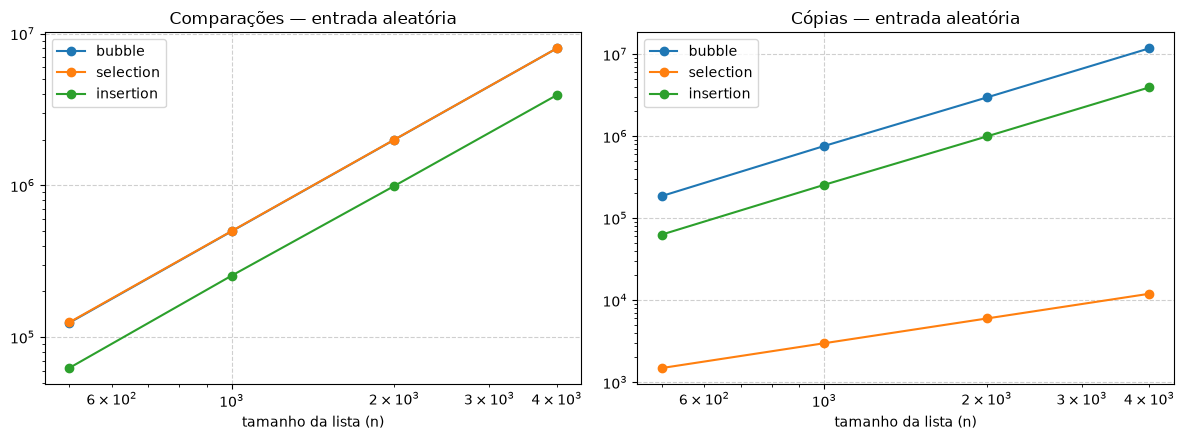

In [6]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4.5))
for nome in ALGORITMOS:
    parte = resultados[(resultados["algoritmo"] == nome) & (resultados["padrao"] == "aleatorio")]
    eixos[0].plot(parte["n"], parte["comparacoes"], marker="o", label=nome)
    eixos[1].plot(parte["n"], parte["copias"], marker="o", label=nome)
eixos[0].set_title("Comparações — entrada aleatória")
eixos[1].set_title("Cópias — entrada aleatória")
for eixo in eixos:
    eixo.set_xlabel("tamanho da lista (n)")
    eixo.set_xscale("log")
    eixo.set_yscale("log")
    eixo.grid(True, linestyle="--", alpha=0.6)
    eixo.legend()
plt.tight_layout()
plt.show()

Em escala log-log as três curvas têm **inclinação 2**: dobrar `n` multiplica o custo por 4. É o comportamento quadrático aparecendo no gráfico.

## 4. Quem mais se beneficia do "quase ordenado"?

In [7]:
quase = resultados[resultados["padrao"] == "quase ordenado"].pivot(
    index="n", columns="algoritmo", values="comparacoes")
aleat = resultados[resultados["padrao"] == "aleatorio"].pivot(
    index="n", columns="algoritmo", values="comparacoes")

print("comparações no QUASE ORDENADO como fração do ALEATÓRIO (quanto menor, mais o algoritmo aproveitou):\n")
print((quase / aleat).round(4))

comparações no QUASE ORDENADO como fração do ALEATÓRIO (quanto menor, mais o algoritmo aproveitou):

algoritmo  bubble  insertion  selection
n                                      
500        0.0439     0.0114        1.0
1000       0.0319     0.0059        1.0
2000       0.0130     0.0030        1.0
4000       0.0055     0.0015        1.0


**O insertion sort é o que mais ganha.** No quase ordenado ele faz uma fração pequena das comparações do caso aleatório, enquanto o selection não ganha nada (faz sempre o mesmo) e o bubble fica no meio.

**Por quê:** cada comparação do insertion que empurra um elemento para a direita desfaz **exatamente uma inversão** (um par fora de ordem). Então o custo dele é proporcional a `n + d`, onde `d` é o número de inversões. Numa lista quase ordenada `d` é pequeno, e o insertion vira praticamente linear: **O(n + d)**.

O bubble também para cedo, mas só depois de todas as passadas necessárias, e cada passada custa até `n` comparações. Um elemento pequeno que ficou lá no fim anda só **uma posição por passada** para a esquerda — isso atrasa o bubble.

Para provar a relação com `d`, conto as inversões de verdade e comparo com as comparações do insertion. A contagem de inversões usa **divisão e conquista** (é um merge sort que conta os pares fora de ordem enquanto intercala), então sai em O(n log n):

In [8]:
def contar_inversoes(lista):
    # devolve (lista ordenada, número de pares fora de ordem)
    if len(lista) <= 1:
        return lista, 0
    meio = len(lista) // 2
    esquerda, inv_esquerda = contar_inversoes(lista[:meio])
    direita, inv_direita = contar_inversoes(lista[meio:])

    junta = []
    inversoes = inv_esquerda + inv_direita
    i = j = 0
    while i < len(esquerda) and j < len(direita):
        if esquerda[i] <= direita[j]:
            junta.append(esquerda[i])
            i += 1
        else:
            junta.append(direita[j])
            j += 1
            # direita[j] é menor que todos os que ainda sobraram na esquerda
            inversoes += len(esquerda) - i
    junta += esquerda[i:] + direita[j:]
    return junta, inversoes


assert contar_inversoes([3, 1, 2])[1] == 2       # (3,1) e (3,2)
assert contar_inversoes([1, 2, 3])[1] == 0

n = 4000
sensibilidade = []
for trocas in [0, 50, 200, 800, 3200, 12800]:
    lista = list(range(n))
    for _ in range(trocas):
        i = random.randrange(n)
        j = min(n - 1, i + random.randint(1, 10))
        lista[i], lista[j] = lista[j], lista[i]
    d = contar_inversoes(lista)[1]
    _, comparacoes, _ = insertion_sort(lista)
    sensibilidade.append({
        "trocas_aplicadas": trocas, "inversoes (d)": d,
        "comparacoes_insertion": comparacoes,
        "comparacoes / (n + d)": comparacoes / (n + d),
    })

pd.DataFrame(sensibilidade)

,trocas_aplicadas,inversoes (d),comparacoes_insertion,comparacoes / (n + d)
0,0,0,3999,0.999750
1,50,462,4461,0.999776
2,200,1796,5795,0.999827
3,800,6454,10453,0.999904
4,3200,16501,20498,0.999854
5,12800,35165,39162,0.999923


A razão `comparacoes / (n + d)` fica praticamente em **1,0** em todos os níveis de desordem, enquanto `d` cresce centenas de vezes. Isso confirma que o custo do insertion é **Θ(n + d)**: com poucas inversões ele é quase linear, e só vira O(n²) quando `d` chega na casa de n²/4 (lista aleatória).

## 5. Validando a ordenação com uma BST

Insiro todos os elementos numa árvore binária de busca e faço a travessia **in-order** (esquerda → raiz → direita). Pela propriedade da BST, a in-order sai em ordem crescente.

Duas decisões:
- **Repetidos vão para a direita**, assim a in-order devolve todos eles, na ordem certa.
- **Inserção e in-order são iterativas.** Numa entrada já ordenada a BST vira uma "lista torta" com altura `n`. Com n = 4.000, uma versão recursiva estouraria o limite de recursão do Python (1.000 chamadas).

In [9]:
class NoArvore:
    def __init__(self, chave):
        self.chave = chave
        self.esquerda = None
        self.direita = None


class BinarySearchTree:
    def __init__(self):
        self.raiz = None
        self.tamanho = 0

    def insert(self, chave):
        """Insere e devolve quantas comparações de chave gastou."""
        novo = NoArvore(chave)
        self.tamanho += 1
        if self.raiz is None:
            self.raiz = novo
            return 0
        comparacoes = 0
        atual = self.raiz
        while True:
            comparacoes += 1
            if chave < atual.chave:
                if atual.esquerda is None:
                    atual.esquerda = novo
                    return comparacoes
                atual = atual.esquerda
            else:   # repetidos vão para a direita
                if atual.direita is None:
                    atual.direita = novo
                    return comparacoes
                atual = atual.direita

    def search(self, chave):
        atual = self.raiz
        while atual is not None:
            if chave == atual.chave:
                return atual
            atual = atual.esquerda if chave < atual.chave else atual.direita
        return None

    def in_order(self):
        # in-order com pilha explícita: desce tudo à esquerda, visita, vai para a direita
        resultado = []
        pilha = []
        atual = self.raiz
        while pilha or atual is not None:
            while atual is not None:
                pilha.append(atual)
                atual = atual.esquerda
            atual = pilha.pop()
            resultado.append(atual.chave)
            atual = atual.direita
        return resultado

    def altura(self):
        # altura contada em níveis, percorrendo por largura
        if self.raiz is None:
            return 0
        nivel, altura = [self.raiz], 0
        while nivel:
            altura += 1
            nivel = [filho for no in nivel for filho in (no.esquerda, no.direita) if filho]
        return altura


def bst_sort(lista):
    """Ordena inserindo tudo na BST e lendo in-order. Devolve (ordenada, comparacoes, arvore)."""
    arvore = BinarySearchTree()
    comparacoes = 0
    for valor in lista:
        comparacoes += arvore.insert(valor)
    return arvore.in_order(), comparacoes, arvore


# a in-order confere com sorted(), inclusive com valores repetidos
original = gerar_padrao(1000, "aleatorio")
ordenada, _, arvore = bst_sort(original)
assert ordenada == sorted(original)
assert bst_sort([3, 1, 4, 1, 5, 9, 2, 6, 5, 3])[0] == [1, 1, 2, 3, 3, 4, 5, 5, 6, 9]
print(f"BST com {arvore.tamanho} nós e altura {arvore.altura()}: in-order conferida com sorted()")

BST com 1000 nós e altura 20: in-order conferida com sorted()


### Custo: ordenar pela BST × insertion sort

A in-order não compara chaves — só percorre os `n` nós, O(n). **Todo o custo da BST está nas inserções**: cada inserção desce um caminho da raiz até uma folha, custando O(altura).

In [10]:
comparacao = []
for n in TAMANHOS:
    for padrao in ["ordenado", "aleatorio"]:
        entrada = gerar_padrao(n, padrao)
        _, comp_bst, arvore = bst_sort(entrada)
        _, comp_ins, _ = insertion_sort(entrada)
        comparacao.append({
            "padrao": padrao, "n": n,
            "bst_comparacoes": comp_bst, "bst_altura": arvore.altura(),
            "insertion_comparacoes": comp_ins,
            "bst / insertion": comp_bst / comp_ins,
        })

pd.DataFrame(comparacao)

,padrao,n,bst_comparacoes,bst_altura,insertion_comparacoes,bst / insertion
0,ordenado,500,124750,500,499,250.000000
1,aleatorio,500,4520,19,58731,0.076961
2,ordenado,1000,499500,1000,999,500.000000
3,aleatorio,1000,11702,24,249857,0.046835
4,ordenado,2000,1999000,2000,1999,1000.000000
5,aleatorio,2000,23826,26,1013247,0.023515
6,ordenado,4000,7998000,4000,3999,2000.000000
7,aleatorio,4000,55390,25,4024304,0.013764


**O melhor caso de um é o pior caso do outro:**

| entrada | insertion sort | ordenar pela BST |
|---|---|---|
| **ordenada** | O(n) — nunca desloca | **O(n²)** — a árvore vira uma lista torta (altura = n) e cada inserção desce até o fim |
| **aleatória** | **O(n²)** — em média n²/4 comparações | O(n log n) — altura perto de 2·log₂ n |

Na tabela: com entrada ordenada a BST tem **altura igual a n** e faz milhares de vezes mais comparações que o insertion; com entrada aleatória a altura fica baixa e a BST ganha com folga.

Além disso a BST custa **O(n) de memória extra** (um nó por elemento), enquanto o insertion ordena no próprio lugar. Então não existe "a BST é melhor": depende de como os dados costumam chegar. Dados que já chegam quase ordenados (logs, ids sequenciais) são o pior caso da BST e o melhor do insertion.

## 6. Remoção na BST — os três casos

O enunciado deste exercício pede inserção e in-order, mas a remoção completa faz parte do que se espera de uma BST, então implemento e testo aqui os três casos:

| caso | o que acontece |
|---|---|
| **folha** | o pai passa a apontar para `None` |
| **um filho** | o pai passa a apontar direto para o neto |
| **dois filhos** | o nó recebe a chave do **sucessor in-order** (a menor chave da subárvore direita) e o sucessor é removido no lugar dele |

O sucessor in-order cabe na vaga porque é a menor chave maior que a removida — não viola a ordenação. E ele tem no máximo um filho (à direita), então removê-lo cai num dos casos simples.

In [11]:
def delete(arvore, chave):
    """Remove uma ocorrência de `chave`. Devolve True se removeu, False se não achou."""
    pai, atual = None, arvore.raiz
    while atual is not None and atual.chave != chave:
        pai = atual
        atual = atual.esquerda if chave < atual.chave else atual.direita
    if atual is None:
        return False

    # dois filhos: copio o sucessor in-order para cá e passo a remover o sucessor
    if atual.esquerda is not None and atual.direita is not None:
        pai_sucessor, sucessor = atual, atual.direita
        while sucessor.esquerda is not None:
            pai_sucessor, sucessor = sucessor, sucessor.esquerda
        atual.chave = sucessor.chave
        pai, atual = pai_sucessor, sucessor

    # agora `atual` tem no máximo um filho: o pai aponta direto para ele
    filho = atual.esquerda if atual.esquerda is not None else atual.direita
    if pai is None:
        arvore.raiz = filho
    elif pai.esquerda is atual:
        pai.esquerda = filho
    else:
        pai.direita = filho
    arvore.tamanho -= 1
    return True


def validar(arvore):
    """Confere a propriedade da BST com limites herdados de cima (não só pai × filho)."""
    contados = 0
    pilha = [(arvore.raiz, None, None)]
    while pilha:
        no, minimo, maximo = pilha.pop()
        if no is None:
            continue
        contados += 1
        assert minimo is None or no.chave >= minimo, f"{no.chave} deveria ser >= {minimo}"
        assert maximo is None or no.chave < maximo, f"{no.chave} deveria ser < {maximo}"
        pilha.append((no.esquerda, minimo, no.chave))
        pilha.append((no.direita, no.chave, maximo))
    assert contados == arvore.tamanho, "o tamanho não bate com os nós alcançáveis"


def arvore_exemplo():
    #          50
    #        /    \
    #      30      70
    #     /  \    /  \
    #   20   40  60   80
    #                   \
    #                    90
    arvore = BinarySearchTree()
    for chave in [50, 30, 70, 20, 40, 60, 80, 90]:
        arvore.insert(chave)
    return arvore


# caso 1 — folha: o 20 não tem filhos
a = arvore_exemplo()
assert delete(a, 20) and a.raiz.esquerda.esquerda is None
validar(a)
print("folha removida    →", a.in_order())

# caso 2 — um filho: o 80 só tem o 90
a = arvore_exemplo()
assert delete(a, 80) and a.raiz.direita.direita.chave == 90   # o 70 apontou direto para o neto
validar(a)
print("um filho removido →", a.in_order())

# caso 3 — dois filhos: o 30 tem o 20 e o 40; o sucessor in-order é o 40
a = arvore_exemplo()
assert delete(a, 30) and a.raiz.esquerda.chave == 40 and a.raiz.esquerda.direita is None
validar(a)
print("dois filhos       →", a.in_order(), " (o 40 assumiu o lugar do 30)")

# a raiz também pode ser removida, e chave ausente não quebra nada
a = arvore_exemplo()
assert delete(a, 50) and not delete(a, 999)
validar(a)

# sequência longa: insere 300 valores, remove todos em ordem aleatória, validando a cada passo
a = BinarySearchTree()
valores = gerar_padrao(300, "aleatorio")
for v in valores:
    a.insert(v)
random.shuffle(valores)
for v in valores:
    assert delete(a, v)
    validar(a)
    assert a.in_order() == sorted(a.in_order())
assert a.raiz is None and a.tamanho == 0
print("\n300 remoções em ordem aleatória: a árvore continuou válida a cada passo e terminou vazia")

folha removida    → [30, 40, 50, 60, 70, 80, 90]
um filho removido → [20, 30, 40, 50, 60, 70, 90]
dois filhos       → [20, 40, 50, 60, 70, 80, 90]  (o 40 assumiu o lugar do 30)

300 remoções em ordem aleatória: a árvore continuou válida a cada passo e terminou vazia


Os `assert` olham a **estrutura** (qual ponteiro mudou), não só a in-order. E o `validar` usa limites herdados: um nó da subárvore esquerda da raiz precisa ser menor que a raiz, não só menor que o próprio pai — conferir só pai × filho deixaria passar árvores erradas.

## 7. Casos de borda

In [12]:
for nome, ordenar in ALGORITMOS.items():
    assert ordenar([]) == ([], 0, 0), nome                 # lista vazia: nada a fazer
    assert ordenar([7])[0] == [7], nome                    # um elemento
    assert ordenar([2, 2, 2])[0] == [2, 2, 2], nome        # todos iguais
    assert ordenar([5, -1, 0, -1])[0] == [-1, -1, 0, 5], nome   # negativos e repetidos

# lista toda igual: bubble e insertion param logo, sem mover nada
assert bubble_sort([2] * 100)[2] == 0
assert insertion_sort([2] * 100)[1] == 99

# BST vazia e BST com um nó
vazia = BinarySearchTree()
assert vazia.in_order() == [] and vazia.altura() == 0 and not delete(vazia, 1)
um = BinarySearchTree()
um.insert(5)
assert um.in_order() == [5] and delete(um, 5) and um.raiz is None

print("todos os casos de borda passaram")

todos os casos de borda passaram


## Resumo

| algoritmo | melhor caso | caso médio | pior caso | trocas ou deslocamentos |
|---|---|---|---|---|
| bubble (com parada antecipada) | O(n) — já ordenado | O(n²) | O(n²) | até 3 cópias por inversão |
| selection | O(n²) | O(n²) | O(n²) | no máximo n trocas |
| insertion | O(n) — já ordenado | O(n²) | O(n²) | 1 cópia por inversão |
| **insertion em lista quase ordenada** | | **O(n + d)** | | |
| ordenar pela BST | O(n log n) | O(n log n) | O(n²) — entrada ordenada | O(n) de memória |

Cada linha está sustentada por uma tabela deste notebook: as comparações idênticas no reverso, o selection constante nos quatro padrões, a razão `comparacoes / (n + d)` fixa em 1,0 e a altura da BST igual a `n` na entrada ordenada.